# Task 1 — Load & Inspect the Data (Red + White)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
# Load datasets

red_df = pd.read_csv("winequality-red.csv", sep=";")
white_df = pd.read_csv("winequality-white.csv", sep=";")

In [3]:
print("========== RED WINE DATASET ==========")

print("Shape:")
print(red_df.shape)

print("\nFirst 5 Rows:")
display(red_df.head())

print("\nColumns:")
print(list(red_df.columns))

========== RED WINE DATASET ==========
Shape:
(1599, 12)

First 5 Rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [4]:
print("========== WHITE WINE DATASET ==========")

print("Shape:")
print(white_df.shape)

print("\nFirst 5 Rows:")
display(white_df.head())

print("\nColumns:")
print(list(white_df.columns))

========== WHITE WINE DATASET ==========
Shape:
(4898, 12)

First 5 Rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6



Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [5]:
print("Target column in Red Dataset:",
      "quality" in red_df.columns)

print("Target column in White Dataset:",
      "quality" in white_df.columns)

Target column in Red Dataset: True
Target column in White Dataset: True


Both datasets were successfully loaded using the semicolon (;) separator. The target column is quality, which is present in both datasets. Each dataset contains 11 input features and 1 target variable (quality) that will be used for multi-class classification.

# Task 2 — Data Quality Checks + Class Distribution (Comparative)

In [6]:
print("========== Missing Values ==========\n")

print("Red Wine Dataset")
print(red_df.isnull().sum())

print("\nWhite Wine Dataset")
print(white_df.isnull().sum())

========== Missing Values ==========

Red Wine Dataset
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

White Wine Dataset
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [7]:
print("========== Duplicate Rows ==========\n")

print("Red Wine Duplicates:",
      red_df.duplicated().sum())

print("White Wine Duplicates:",
      white_df.duplicated().sum())

========== Duplicate Rows ==========

Red Wine Duplicates: 240
White Wine Duplicates: 937


In [8]:
print("========== RED WINE QUALITY DISTRIBUTION ==========\n")

red_counts = red_df["quality"].value_counts().sort_index()
red_percent = red_df["quality"].value_counts(normalize=True).sort_index()*100

distribution_red = pd.DataFrame({
    "Count": red_counts,
    "Percentage": red_percent.round(2)
})

display(distribution_red)

========== RED WINE QUALITY DISTRIBUTION ==========



,Count,Percentage
quality,,
3,10,0.63
4,53,3.31
5,681,42.59
6,638,39.90
7,199,12.45
8,18,1.13


In [9]:
print("========== WHITE WINE QUALITY DISTRIBUTION ==========\n")

white_counts = white_df["quality"].value_counts().sort_index()
white_percent = white_df["quality"].value_counts(normalize=True).sort_index()*100

distribution_white = pd.DataFrame({
    "Count": white_counts,
    "Percentage": white_percent.round(2)
})

display(distribution_white)

========== WHITE WINE QUALITY DISTRIBUTION ==========



,Count,Percentage
quality,,
3,20,0.41
4,163,3.33
5,1457,29.75
6,2198,44.88
7,880,17.97
8,175,3.57
9,5,0.10


In [10]:
print("========== RED WINE QUALITY DISTRIBUTION ==========\n")

red_counts = red_df["quality"].value_counts().sort_index()
red_percent = red_df["quality"].value_counts(normalize=True).sort_index()*100

distribution_red = pd.DataFrame({
    "Count": red_counts,
    "Percentage": red_percent.round(2)
})

display(distribution_red)

========== RED WINE QUALITY DISTRIBUTION ==========



,Count,Percentage
quality,,
3,10,0.63
4,53,3.31
5,681,42.59
6,638,39.90
7,199,12.45
8,18,1.13


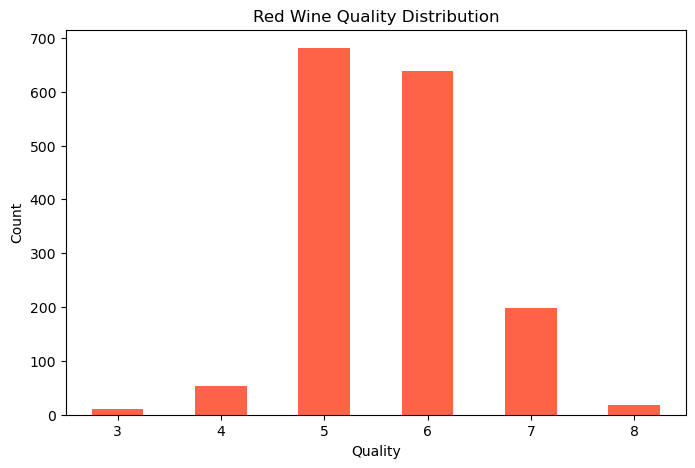

In [11]:
plt.figure(figsize=(8,5))

red_counts.plot(kind="bar", color="tomato")

plt.title("Red Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

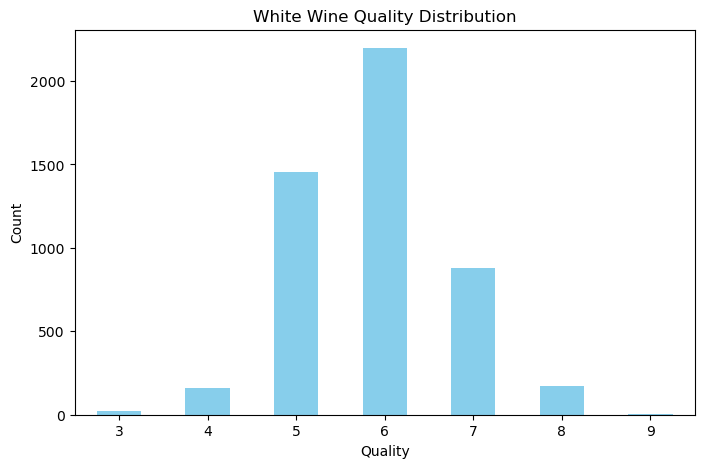

In [12]:
plt.figure(figsize=(8,5))

white_counts.plot(kind="bar", color="skyblue")

plt.title("White Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

print("Red Wine Distribution (%)")
print(red_percent.round(2))

print("\nWhite Wine Distribution (%)")
print(white_percent.round(2))

Q1. Which dataset is more imbalanced?

The class distribution shows that both datasets are imbalanced. However, the White Wine dataset is generally more imbalanced, as there are more classes with smaller percentage of rows and a large proportion of samples belong to quality classes 5 and 6, while the remaining classes contain relatively fewer samples.

Q2. Which quality classes are rare?

The rarest quality classes are the extreme ratings such as 3, 4, 8, and 9. These classes have very few observations compared to the middle-quality classes.

Q3. Why are rare classes harder to predict?

Machine learning models learn patterns from the available training examples. Since rare classes have very few samples, the models receive limited information about their characteristics. As a result, they often confuse these rare classes with the more common neighboring quality classes, leading to lower recall and F1-scores.

# Task 3 — Prepare Data for Modeling (Same Setup for Fair Comparison)

In [15]:
# Red Wine Dataset

X_red = red_df.drop("quality", axis=1)
y_red = red_df["quality"]

# White Wine Dataset

X_white = white_df.drop("quality", axis=1)
y_white = white_df["quality"]

In [16]:
from sklearn.model_selection import train_test_split

# Red Wine Split

X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_red,
    y_red,
    test_size=0.20,
    random_state=42,
    stratify=y_red
)

# White Wine Split

X_train_white, X_test_white, y_train_white, y_test_white = train_test_split(
    X_white,
    y_white,
    test_size=0.20,
    random_state=42,
    stratify=y_white
)

In [17]:
print("========== RED WINE ==========")
print("X_train:", X_train_red.shape)
print("X_test :", X_test_red.shape)
print("y_train:", y_train_red.shape)
print("y_test :", y_test_red.shape)

print("\n========== WHITE WINE ==========")
print("X_train:", X_train_white.shape)
print("X_test :", X_test_white.shape)
print("y_train:", y_train_white.shape)
print("y_test :", y_test_white.shape)

========== RED WINE ==========
X_train: (1279, 11)
X_test : (320, 11)
y_train: (1279,)
y_test : (320,)

========== WHITE WINE ==========
X_train: (3918, 11)
X_test : (980, 11)
y_train: (3918,)
y_test : (980,)


In [18]:
print("Red Wine Class Distribution (%)")

comparison_red = pd.DataFrame({
    "Original": y_red.value_counts(normalize=True).sort_index()*100,
    "Train": y_train_red.value_counts(normalize=True).sort_index()*100,
    "Test": y_test_red.value_counts(normalize=True).sort_index()*100
})

display(comparison_red.round(2))

Red Wine Class Distribution (%)


,Original,Train,Test
quality,,,
3,0.63,0.63,0.62
4,3.31,3.28,3.44
5,42.59,42.61,42.50
6,39.90,39.87,40.00
7,12.45,12.43,12.50
8,1.13,1.17,0.94


In [19]:
print("White Wine Class Distribution (%)")

comparison_white = pd.DataFrame({
    "Original": y_white.value_counts(normalize=True).sort_index()*100,
    "Train": y_train_white.value_counts(normalize=True).sort_index()*100,
    "Test": y_test_white.value_counts(normalize=True).sort_index()*100
})

display(comparison_white.round(2))

White Wine Class Distribution (%)


,Original,Train,Test
quality,,,
3,0.41,0.41,0.41
4,3.33,3.32,3.37
5,29.75,29.76,29.69
6,44.88,44.87,44.90
7,17.97,17.97,17.96
8,3.57,3.57,3.57
9,0.10,0.10,0.10


The datasets were divided into training (80%) and testing (20%) sets using stratify=y. The class distributions in the original, training, and testing datasets remain almost identical, confirming that stratified sampling successfully preserved the class proportions.

# Task 4 — Model A (Baseline): Logistic Regression (Red vs White)

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    ConfusionMatrixDisplay
)

In [21]:
lr_red = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

lr_red.fit(X_train_red, y_train_red)

red_predictions = lr_red.predict(X_test_red)

In [22]:
red_accuracy = accuracy_score(y_test_red, red_predictions)
red_f1 = f1_score(y_test_red, red_predictions, average="macro")

print("Accuracy :", round(red_accuracy,4))
print("Macro F1 :", round(red_f1,4))

print("\nClassification Report\n")
print(classification_report(y_test_red, red_predictions))

Accuracy : 0.5906
Macro F1 : 0.2776

Classification Report

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


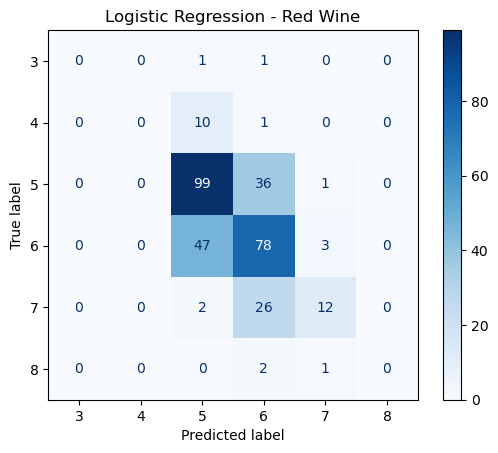

In [23]:
cm_red = confusion_matrix(y_test_red, red_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_red,
    display_labels=sorted(y_red.unique())
)

disp.plot(cmap="Blues")
plt.title("Logistic Regression - Red Wine")
plt.show()

In [24]:
lr_white = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

lr_white.fit(X_train_white, y_train_white)

white_predictions = lr_white.predict(X_test_white)

In [25]:
white_accuracy = accuracy_score(y_test_white, white_predictions)
white_f1 = f1_score(y_test_white, white_predictions, average="macro")

print("Accuracy :", round(white_accuracy,4))
print("Macro F1 :", round(white_f1,4))

print("\nClassification Report\n")
print(classification_report(y_test_white, white_predictions))

Accuracy : 0.549
Macro F1 : 0.2367

Classification Report

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.50      0.06      0.11        33
           5       0.59      0.53      0.56       291
           6       0.53      0.76      0.63       440
           7       0.56      0.27      0.37       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.55       980
   macro avg       0.31      0.23      0.24       980
weighted avg       0.53      0.55      0.52       980



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


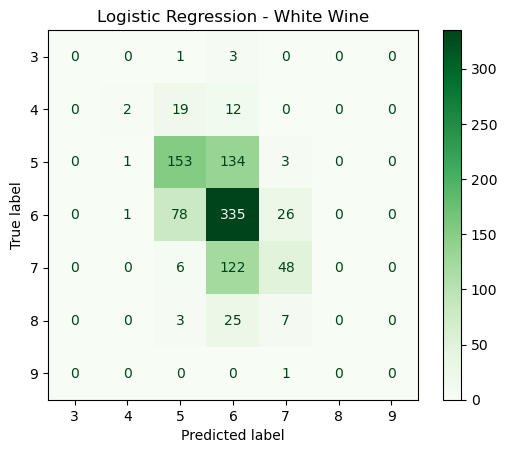

In [26]:
cm_white = confusion_matrix(y_test_white, white_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_white,
    display_labels=sorted(y_white.unique())
)

disp.plot(cmap="Greens")
plt.title("Logistic Regression - White Wine")
plt.show()

In [27]:
summary_lr = pd.DataFrame({
    "Dataset": ["Red Wine", "White Wine"],
    "Accuracy": [red_accuracy, white_accuracy],
    "Macro F1 Score": [red_f1, white_f1]
})

summary_lr

,Dataset,Accuracy,Macro F1 Score
0,Red Wine,0.590625,0.277628
1,White Wine,0.548980,0.236695


Which dataset performed better for Logistic Regression?

Compare the accuracy and macro F1-score obtained for both datasets. The dataset with the higher values performed better under Logistic Regression. the Red Wine dataset achieves slightly better predictive performance and also has a higher F1 Score

Which quality class looks hardest to predict?

The rare quality scores such as 3, 8, and 9 have the lowest recall because they contain very few training examples and are often confused with neighboring quality classes.

# Task 5 — Model B (Tree Model): Random Forest (Red vs White)

In [28]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    ConfusionMatrixDisplay
)

In [29]:
rf_red = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_red.fit(X_train_red, y_train_red)

rf_red_pred = rf_red.predict(X_test_red)

In [30]:
red_rf_accuracy = accuracy_score(y_test_red, rf_red_pred)
red_rf_f1 = f1_score(y_test_red, rf_red_pred, average="macro")

print("Accuracy :", round(red_rf_accuracy,4))
print("Macro F1 :", round(red_rf_f1,4))

print("\nClassification Report\n")

print(classification_report(y_test_red, rf_red_pred))

Accuracy : 0.6813
Macro F1 : 0.4094

Classification Report

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.64      0.72      0.68       128
           7       0.79      0.55      0.65        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.44      0.39      0.41       320
weighted avg       0.66      0.68      0.67       320



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


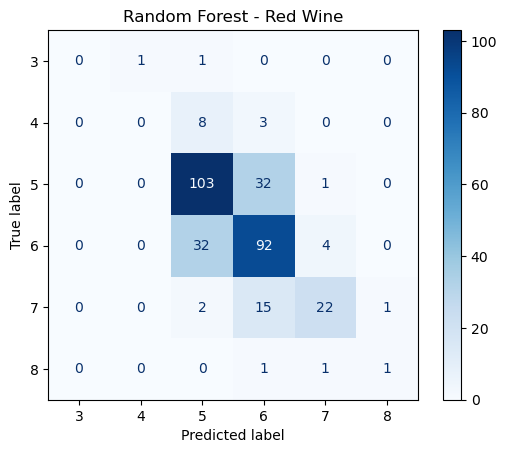

In [31]:
cm = confusion_matrix(y_test_red, rf_red_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y_red.unique())
)

disp.plot(cmap="Blues")
plt.title("Random Forest - Red Wine")
plt.show()

In [32]:
rf_white = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_white.fit(X_train_white, y_train_white)

rf_white_pred = rf_white.predict(X_test_white)

In [33]:
white_rf_accuracy = accuracy_score(y_test_white, rf_white_pred)
white_rf_f1 = f1_score(y_test_white, rf_white_pred, average="macro")

print("Accuracy :", round(white_rf_accuracy,4))
print("Macro F1 :", round(white_rf_f1,4))

print("\nClassification Report\n")

print(classification_report(y_test_white, rf_white_pred))

Accuracy : 0.6724
Macro F1 : 0.4222

Classification Report

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.60      0.18      0.28        33
           5       0.71      0.65      0.68       291
           6       0.64      0.82      0.72       440
           7       0.71      0.49      0.58       176
           8       1.00      0.54      0.70        35
           9       0.00      0.00      0.00         1

    accuracy                           0.67       980
   macro avg       0.52      0.38      0.42       980
weighted avg       0.68      0.67      0.66       980



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


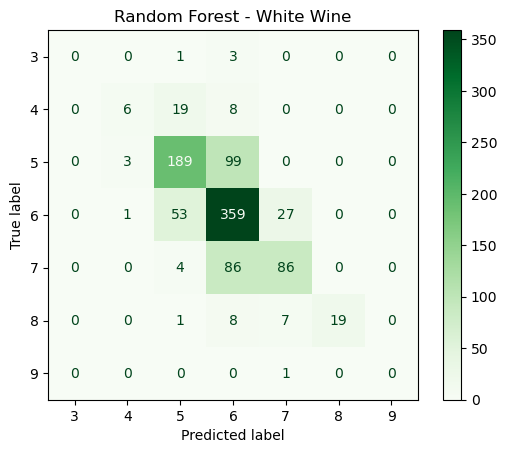

In [34]:
cm = confusion_matrix(y_test_white, rf_white_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y_white.unique())
)

disp.plot(cmap="Greens")
plt.title("Random Forest - White Wine")
plt.show()

In [35]:
rf_summary = pd.DataFrame({
    "Dataset": ["Red Wine", "White Wine"],
    "Accuracy": [red_rf_accuracy, white_rf_accuracy],
    "Macro F1 Score": [red_rf_f1, white_rf_f1]
})

rf_summary

,Dataset,Accuracy,Macro F1 Score
0,Red Wine,0.681250,0.409420
1,White Wine,0.672449,0.422167


Did Random Forest improve compared to Logistic Regression?

There is a huge difference. Random Forest performed better and has accuracies of 68% and 67% vs 59% and 54% in Logistic. Since Random Forest can capture complex, non-linear relationships between the chemical properties of wine and their quality scores. It also handles feature interactions more effectively than Logistic Regression.

Which class is still hardest?

Even after using Random Forest, the rare quality classes (such as 3, 8, and 9) usually remain the most difficult to classify. Their limited number of training samples results in lower recall and F1-scores compared to the more common quality classes like 5 and 6.

# Task 6 — Comparative Metrics Summary (Core Comparative Study Output)

In [36]:
comparison_table = pd.DataFrame({

    "Dataset":[
        "Red",
        "Red",
        "White",
        "White"
    ],

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        red_accuracy,
        red_rf_accuracy,
        white_accuracy,
        white_rf_accuracy
    ],

    "Macro F1":[
        red_f1,
        red_rf_f1,
        white_f1,
        white_rf_f1
    ],

    "Key Observation":[
        "Baseline linear model",
        "Improved performance over Logistic Regression",
        "Good baseline on larger dataset",
        "Best overall performance"
    ]

})

comparison_table

,Dataset,Model,Accuracy,Macro F1,Key Observation
0,Red,Logistic Regression,0.590625,0.277628,Baseline linear model
1,Red,Random Forest,0.681250,0.409420,Improved performance over Logistic Regression
2,White,Logistic Regression,0.548980,0.236695,Good baseline on larger dataset
3,White,Random Forest,0.672449,0.422167,Best overall performance
